In [ ]:
#Project Data Analysis
#1.Load Data
#sub Q
#Display first 10 rows
#Display last 5 rows

import pandas as pd
df=pd.read_csv("customers-100 (2).csv")
print(df.head(10))
print(df.tail(5))


In [ ]:
#2.Dataset Information
# find
#find Total Rows and columns
print(df.shape)

#Column names
print(df.axes)#print(df.columns)

#Data types
print(df.dtypes)

#Missing alues
print(df.isnull().sum())

In [5]:
#3. Customer Analysis

#1.Count total customers.
#print("Total customers: ",df["Index"].count())
#OR
print("Total Customer: ",len(df))

#2.Count unique cities.
print("unique cities: ",df['City'].nunique())
#OR
# print(df["City"].value_counts())

#3.Count unique countries.
print("unique countries: ",df['Country'].nunique())
#OR
#print(df["Country"].value_counts())

#4.Count unique companies.
# print(df["Company"].value_counts())
#OR 
print("unique companies",df['Company'].nunique())

Total Customer:  100
unique cities:  11
unique countries:  1
unique companies 13


In [ ]:
#4. Filtering Data

#Show customers:

#a.From India
newdf=df[df["Country"]=="India"]
print(newdf)

In [ ]:
#b.From Mumbai
newdf=df[df["City"]=="Mumbai"]
print(newdf)

In [ ]:
#c.Having Gmail accounts
newdf=df[df["Email"].str.contains("gmail.com",na=False)]
print(newdf)

In [60]:
# Convert Subscription Date to datetime

df['Subscription Date'] = pd.to_datetime(df['Subscription Date'],format="mixed")
print(df['Subscription Date'].dtype)

#d.Subscription after 2024
sub_after_2024 = df[df['Subscription Date'].dt.year > 2024]
print("\nSUBSCRIPTIONS AFTER 2024")
print(sub_after_2024)

datetime64[ns]

SUBSCRIPTIONS AFTER 2024
Empty DataFrame
Columns: [Index, Customer Id, First Name, Last Name, Company, City, Country, Phone 1, Phone 2, Email, Subscription Date, Website, Full Name, Email Domain, Website Domain, Year, Month]
Index: []


In [ ]:
#5. Sorting Data

#Q.Sort customers by:

#a.First Name
print(df.sort_values(by="First Name"))


In [ ]:
#b.by Country
print(df.sort_values(by="Country"))


In [ ]:
#c.by Subscription Date
print(df.sort_values(by="Subscription Date"))


In [ ]:
#🔹 Part B — Data Cleaning Questions
#6. Missing Data
#a.Find rows with missing email.
newdf=df[df["Email"].isnull()]
print(newdf)
#b.Replace missing phone numbers with "Not Available"
df["Phone 1"] = df["Phone 1"].fillna("Not Available")
print(df["Phone 1"])
df["Phone 2"] = df["Phone 2"].fillna("Not Available")
print(df["Phone 2"])


In [ ]:
#7. Duplicate Records
#a.Find duplicate customers.
print("\nDUPLICATE RECORDS")
print(df[df.duplicated()])

#b.Remove duplicates.
print(df.drop_duplicates)
#after removing
print(df.shape)

In [ ]:
#8. Create New Columns

#Create:
#a.Full Name = First Name + Last Name
df["Full Name"]=df["First Name"] +" "+ df["Last Name"]
print(df["Full Name"])


0        Aarav Sharma
1          Diya Patel
2        Vihaan Mehta
3         Anaya Reddy
4        Arjun Kapoor
           ...       
95        Saanika Dua
96      Rehaan Luthra
97        Kiara Monga
98        Advik Sidhu
99    Samaira Khattar
Name: Full Name, Length: 100, dtype: object


In [70]:
#9. EMAIL DOMAIN ANALYSIS

#a. Extract domain

df['Email Domain'] = df['Email'].str.split('@').str[-1]
print(df['Email Domain'])

#b. Count domains
print(df['Email Domain'].value_counts())

#c. Gmail count
print((df['Email Domain'] == 'gmail.com').sum())

#d. Yahoo count
print((df['Email Domain'] == 'yahoo.com').sum())

#e. Outlook count
print((df['Email Domain'] == 'outlook.com').sum())


0       gmail.com
1       yahoo.com
2     outlook.com
3       gmail.com
4       gmail.com
         ...     
95      yahoo.com
96      gmail.com
97      gmail.com
98      yahoo.com
99      gmail.com
Name: Email Domain, Length: 100, dtype: object
Email Domain
gmail.com      60
yahoo.com      29
outlook.com    11
Name: count, dtype: int64
60
29
11


In [72]:
#10. Website Analysis
#a.Count .com, .org, .net websites.
print("Webiste.com: ",df["Website"].str.contains(".com",na=False).sum())
print("Webiste.org: ",df["Website"].str.contains(".org",na=False).sum())
print("Webiste.net: ",df["Website"].str.contains(".net",na=False).sum())
#print("Webiste.in: ",df["Website"].str.contains(".in",na=False).str[-1].sum())

#b.Find most common website domain.
df['Website Domain'] = df['Website'].str.split('.').str[-1] 
print(df['Website Domain'].mode())

Webiste.com:  30
Webiste.org:  20
Webiste.net:  20
0    com
1     in
Name: Website Domain, dtype: object


In [ ]:
#11. Country-wise Customer Count

#a.Find number of customers in each country.
country_count=df.groupby("Country")["Index"].count()
print(country_count)

Country
India    100
Name: Index, dtype: int64


In [3]:
#12. City-wise Analysis

#Find:
#a.Top 10 cities by customer count
#print(df.groupby("City")["Index"].count().sort_values(ascending=False).head(10))
city_count = df['City'].value_counts()

print("\nTOP 10 CITIES")
print(city_count.head(10))



TOP 10 CITIES
City
Mumbai       10
Delhi         9
Pune          9
Chennai       9
Bangalore     9
Hyderabad     9
Kolkata       9
Ahmedabad     9
Lucknow       9
Surat         9
Name: count, dtype: int64


In [ ]:
#13. Company Analysis

#a.Find:
company_count=df.groupby("Company")["Index"].count().sort_values(ascending=False)

#b.Company with most customers.
print(company_count.head(1))
#c.Top 5 companies.
print(company_count.head(5))

Company
ByteWorks    10
Name: Index, dtype: int64
Company
ByteWorks    10
CloudCore    10
DataSoft     10
Innovix      10
NextGen      10
Name: Index, dtype: int64


In [37]:
#14.Subsripition Date
# Customers joined each 
df['Year'] = df['Subscription Date'].dt.year

print("\nCUSTOMERS JOINED EACH YEAR")
print(df['Year'].value_counts().sort_index())

# Customers joined each month

df['Month'] = df['Subscription Date'].dt.month_name()

print("\nCUSTOMERS JOINED EACH MONTH")
print(df['Month'].value_counts().sort_index())


CUSTOMERS JOINED EACH YEAR
Year
2024    100
Name: count, dtype: int64

CUSTOMERS JOINED EACH MONTH
Month
April         5
August        4
December      4
February     19
January      22
July          4
June          4
March        22
May           4
November      4
October       4
September     4
Name: count, dtype: int64


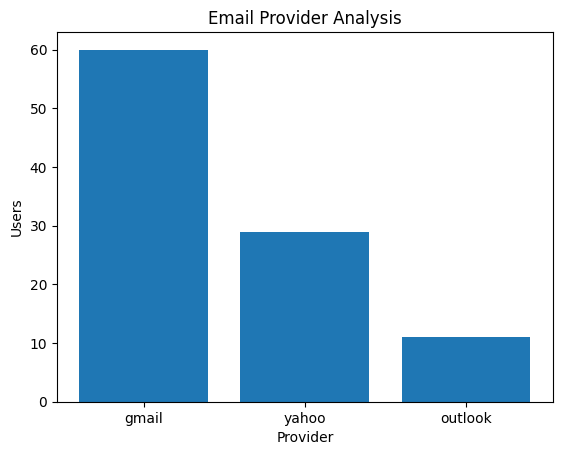

In [22]:
#15. Email Provider Analysis

#Create chart for:

#Gmail users
#Yahoo users
#Outlook 
import matplotlib.pyplot as plt

provider_counts = {
    'gmail': (df['Email Domain'] == 'gmail.com').sum(),
    'yahoo': (df['Email Domain'] == 'yahoo.com').sum(),
    'outlook': (df['Email Domain'] == 'outlook.com').sum()
}

# plt.figure(figsize=(6,4))#doubt
plt.bar(provider_counts.keys(), provider_counts.values())
plt.title('Email Provider Analysis')
plt.xlabel('Provider')
plt.ylabel('Users')
plt.show()

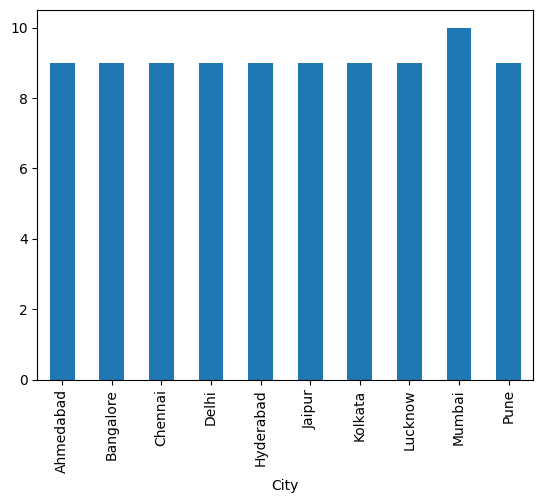

In [23]:
#Part D — Matplotlib Practice
#16. Bar Chart

#Plot:

#Top 10 cities by customers.
import pandas as pd
import matplotlib.pyplot as plt
df.groupby("City")["Index"].count().head(10).plot(kind = "bar",x="City",y="Index")
plt.show()

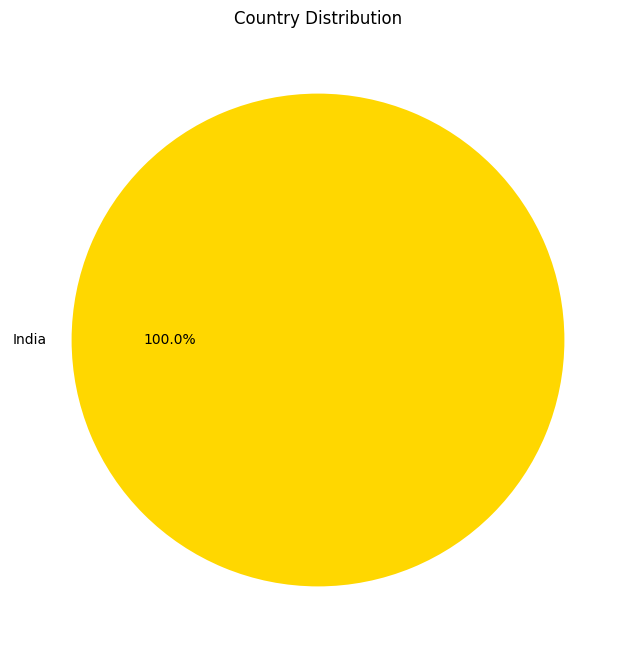

In [113]:
#17. Pie Chart

#Show:

#Country distribution.
plt.figure(figsize=(8,8))
country_count.plot(kind='pie', autopct='%1.1f%%',colors=["gold"])
plt.title('Country Distribution')
plt.ylabel('')
plt.show()

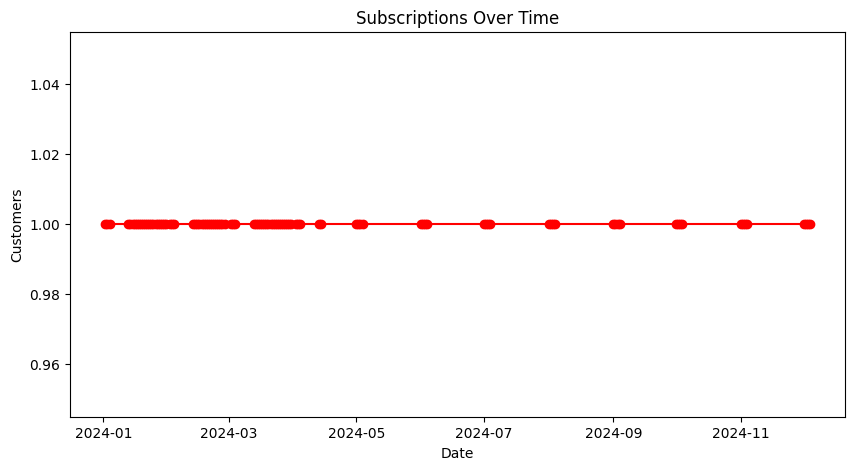

In [112]:
# 18.LINE CHART
subscription_trend = df.groupby('Subscription Date')['Index'].count()

plt.figure(figsize=(10,5))
plt.plot(subscription_trend,c='r',marker='o')

plt.title('Subscriptions Over Time')
plt.xlabel('Date')
plt.ylabel('Customers')
plt.show()

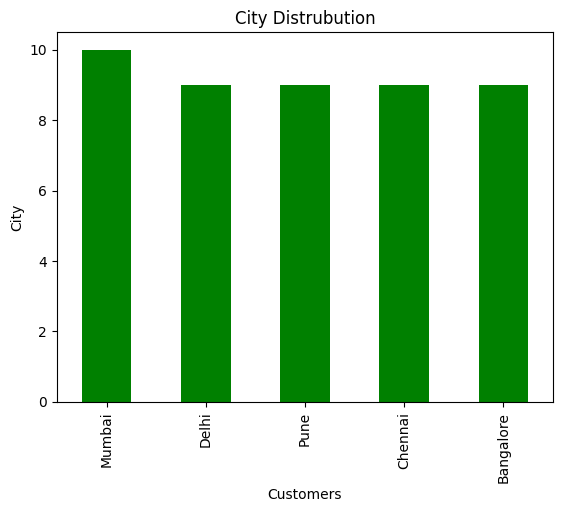

In [77]:
#extra Q
#city Wise Customer
#Bar chart
city_count.head(5).plot(kind='bar',color="g")
plt.title("City Distrubution")
plt.xlabel('Customers')
plt.ylabel('City')
plt.show()

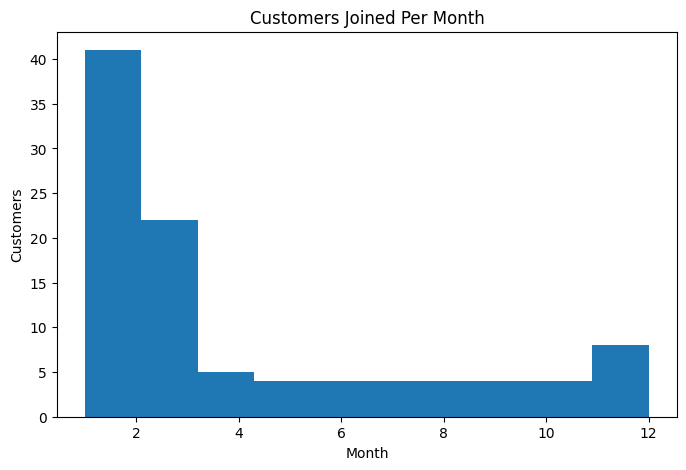

In [ ]:
#19. Histogram

#Plot:

#Customers joined per month.
plt.figure(figsize=(8,5))
plt.hist(df['Month'])
plt.title('Customers Joined Per Month')
plt.xlabel('Month')
plt.ylabel('Customers')
plt.show()

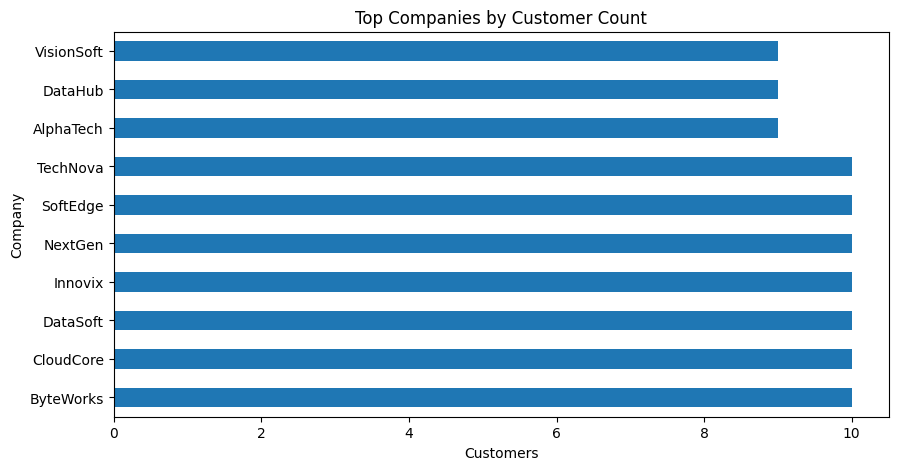

In [27]:
#20. Horizontal Bar Chart

#Plot:

#Top companies by customer 
plt.figure(figsize=(10,5))
company_count.head(10).plot(kind='barh')
plt.title('Top Companies by Customer Count')
plt.xlabel('Customers')
plt.ylabel('Company')
plt.show()



In [28]:
#21. Customer Growth Analysis
#Find customer growth trend over months.

monthly_growth = df.groupby(['Year', 'Month'])['Index'].count()

print("\nCUSTOMER GROWTH TREND")
print(monthly_growth)



CUSTOMER GROWTH TREND
Year  Month
2024  1        22
      2        19
      3        22
      4         5
      5         4
      6         4
      7         4
      8         4
      9         4
      10        4
      11        4
      12        4
Name: Index, dtype: int64


In [29]:
#22. Business Insight Questions

#Answer:

#Which country has most customers?
print(country_count.idxmax())
#Which company has highest registrations?
print(company_count.idxmax())
#Which email provider is most popular?
print(df["Email Domain"].mode())

India
ByteWorks
0    gmail.com
Name: Email Domain, dtype: object


In [30]:
# 23.detect invalid
# Invalid emails
invalid_emails = df[~df['Email'].str.contains('@', na=False)]

print("\nINVALID EMAILS")
print(invalid_emails)

# Missing websites
missing_websites = df[df['Website'].isnull()]

print("\nMISSING WEBSITES")
print(missing_websites)

# Incorrect phone numbers
df['Phone 1'] = df['Phone 1'].astype(str)
incorrect_phone = df[ (df['Phone 1'].str.len() < 10) | (df['Phone 1'].str.len() > 10)]

print("\nINCORRECT PHONE NUMBERS")
print(incorrect_phone)



INVALID EMAILS
Empty DataFrame
Columns: [Index, Customer Id, First Name, Last Name, Company, City, Country, Phone 1, Phone 2, Email, Subscription Date, Website, Full Name, Email Domain, Website Domain, Year, Month]
Index: []

MISSING WEBSITES
Empty DataFrame
Columns: [Index, Customer Id, First Name, Last Name, Company, City, Country, Phone 1, Phone 2, Email, Subscription Date, Website, Full Name, Email Domain, Website Domain, Year, Month]
Index: []

INCORRECT PHONE NUMBERS
    Index Customer Id First Name Last Name    Company    City Country  \
11     12    CUST1012      Kiara  Malhotra   DataSoft  Mumbai   India   
12     13    CUST1013       Yash     Gupta  CloudCore   Delhi   India   

        Phone 1     Phone 2                     Email Subscription Date  \
11    876500022  9122200022  kiara.malhotra@gmail.com        2024-01-16   
12  98765040023  9122200023      yash.gupta@gmail.com        2024-01-17   

              Website       Full Name Email Domain Website Domain  Year  Mo

In [59]:
#24. CUSTOMER SEGMENTATION

# Segment by Country
country_segment=df.groupby("Country")["Index"].count()
print(country_segment)
#Segment by Company
company_segment=df.groupby("Company")["Index"].count().sort_values()
print(company_segment)
#Segment by Email
email_segment = df.groupby('Email Domain')['Index'].count().sort_values()
print(email_segment)

Country
India    100
Name: Index, dtype: int64
Company
Alphaoft       1
DataHuTech     1
VisionSb       1
AlphaTech      9
DataHub        9
VisionSoft     9
ByteWorks     10
CloudCore     10
DataSoft      10
Innovix       10
NextGen       10
SoftEdge      10
TechNova      10
Name: Index, dtype: int64
Email Domain
outlook.com    11
yahoo.com      29
gmail.com      60
Name: Index, dtype: int64


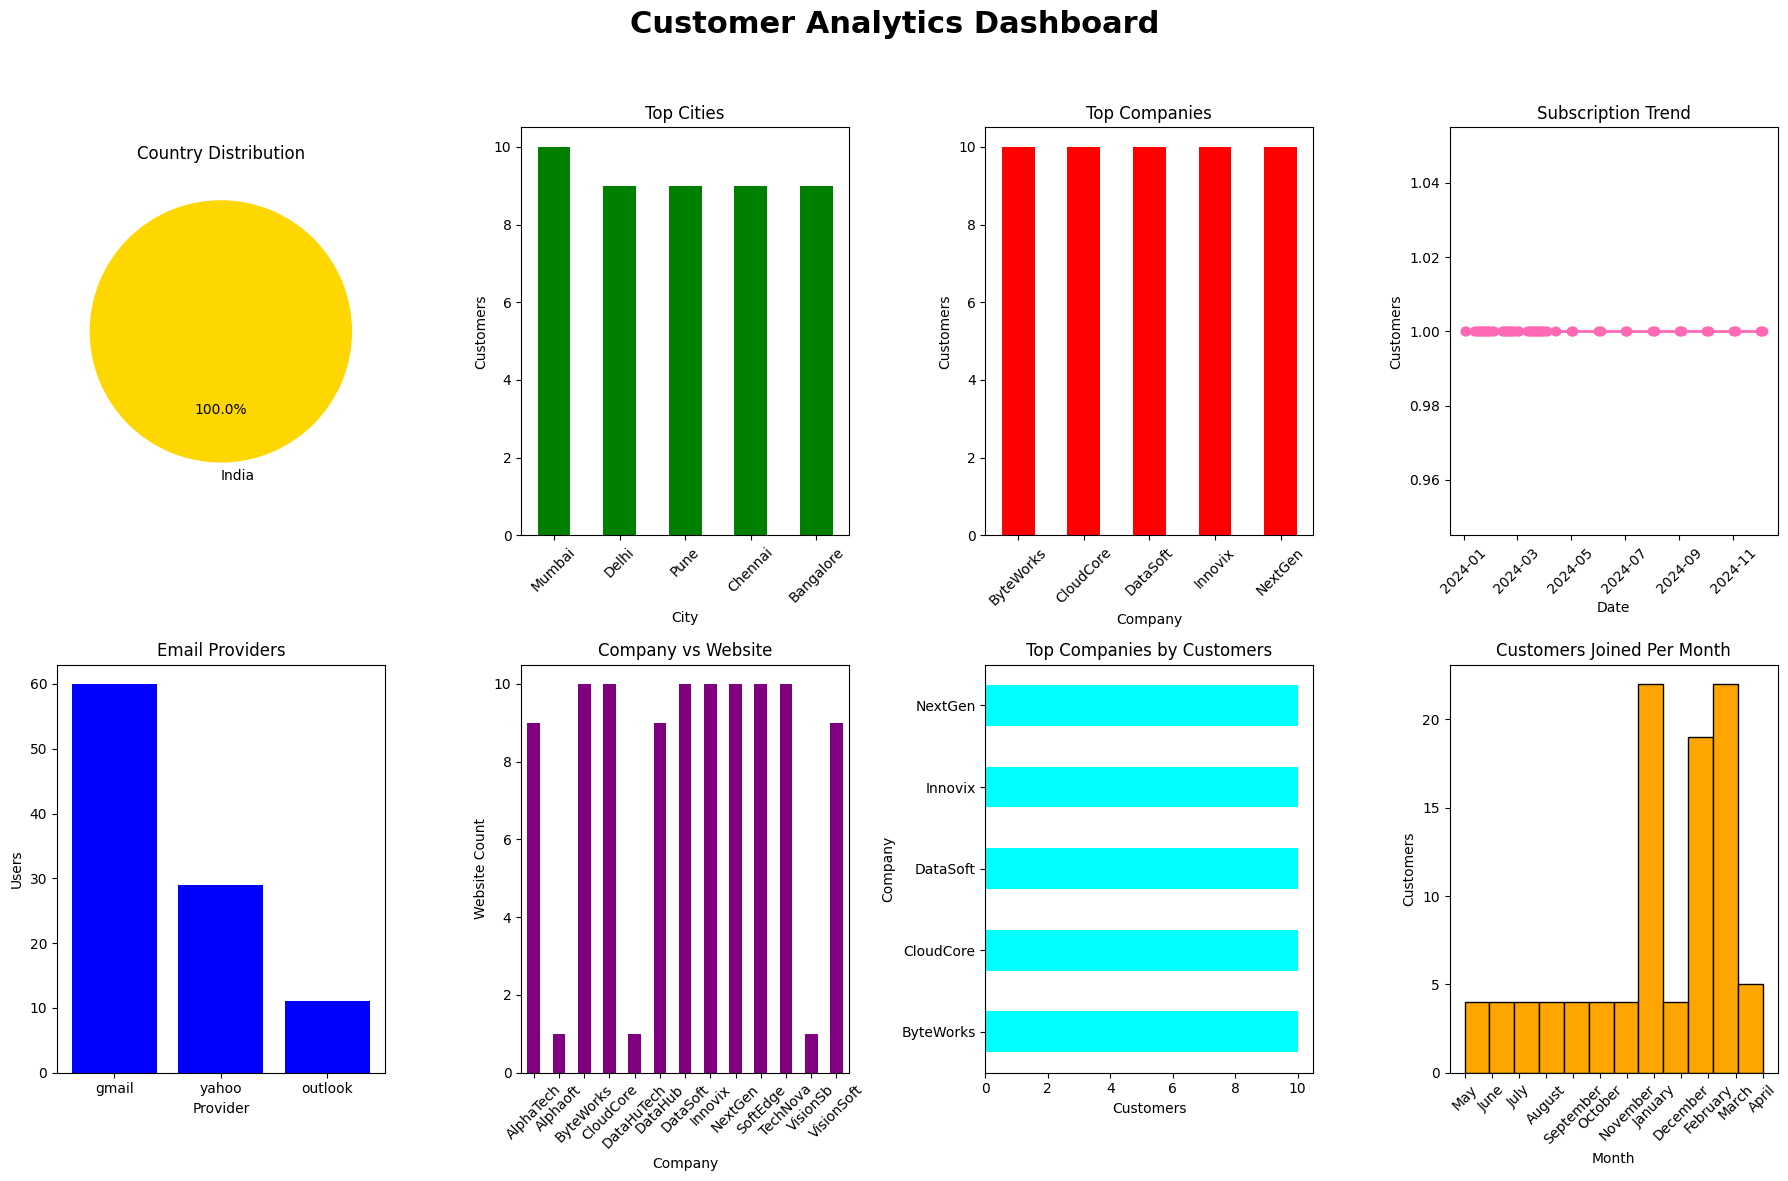


PROJECT COMPLETED SUCCESSFULLY


In [108]:


# =========================
# MAIN DASHBOARD
# =========================

plt.figure(figsize=(18, 12))

# Dashboard title
plt.suptitle('Customer Analytics Dashboard',fontsize=22,fontweight='bold')

# -------------------------
# 1. Country Distribution
# -------------------------
plt.subplot(2, 4, 1)

country_count.plot(kind='pie',autopct='%1.1f%%',colors=['gold'],startangle=90)

plt.title('Country Distribution')
plt.ylabel('')

# -------------------------
# 2. City Distribution
# -------------------------
plt.subplot(2, 4, 2)

city_count.head(5).plot(kind='bar',color='green')

plt.title('Top Cities')
plt.xlabel('City')
plt.ylabel('Customers')
plt.xticks(rotation=45)

# -------------------------
# 3. Company Distribution
# -------------------------
plt.subplot(2, 4, 3)

company_count.head(5).plot(kind='bar',color='red')

plt.title('Top Companies')
plt.xlabel('Company')
plt.ylabel('Customers')
plt.xticks(rotation=45)

# -------------------------
# 4. Subscription Trend
# -------------------------
plt.subplot(2, 4, 4)

plt.plot(subscription_trend,color='hotpink',marker='o',linewidth=2)

plt.title('Subscription Trend')
plt.xlabel('Date')
plt.ylabel('Customers')
plt.xticks(rotation=45)

# -------------------------
# 5. Email Provider Analysis
# -------------------------
plt.subplot(2, 4, 5)

plt.bar(provider_counts.keys(),provider_counts.values(),color='blue')

plt.title('Email Providers')
plt.xlabel('Provider')
plt.ylabel('Users')

# -------------------------
# 6. Website Analysis
# -------------------------
plt.subplot(2, 4, 6)

website_company = df.groupby('Company')['Website'].count()

website_company.plot(kind='bar',color='purple')

plt.title('Company vs Website')
plt.xlabel('Company')
plt.ylabel('Website Count')
plt.xticks(rotation=45)

# -------------------------
# 7. Top Companies by Customers
# -------------------------
plt.subplot(2, 4, 7)

company_count.head(5).plot(kind='barh',color='cyan')

plt.title('Top Companies by Customers')
plt.xlabel('Customers')
plt.ylabel('Company')

# -------------------------
# 8. Customers Joined Per Month
# -------------------------
plt.subplot(2, 4, 8)

plt.hist(df['Month'],bins=12,color='orange',edgecolor='black')

plt.title('Customers Joined Per Month')
plt.xlabel('Month')
plt.ylabel('Customers')
plt.xticks(rotation=45)

# -------------------------
# Layout Adjustment
# -------------------------
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show dashboard
plt.show()

print("\nPROJECT COMPLETED SUCCESSFULLY")